In [3]:
# Install scanpy if not already installed
!pip install scanpy --break-system-packages -q

import scanpy as sc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.size'] = 11
matplotlib.rcParams['figure.dpi'] = 150
from scipy.stats import mannwhitneyu
import os
import warnings
warnings.filterwarnings('ignore')
import time

"""


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 55.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 176.6/176.6 kB 21.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.1/60.1 kB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 284.1/284.1 kB 33.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 144.4 MB/s eta 0:00:00


"\n================================================================================\nv18-C2: AUCell PATHWAY SCORING (Tissue-Separated)\n================================================================================\nVersion: 18 (Liver/Blood tissue-separated re-analysis)\nDataset: GSE182159 (243K cells, 23 donors, 46 samples)\nPurpose: Run AUCell pathway scoring on Liver-only and Blood-only subsets\n         26 gene sets × 59 subclusters × 5 stages × 2 tissues\n         Compare with v17 (combined) pathway scores\nSave path: /content/drive/MyDrive/ITLAS/results/version18-analysis/C2_pathway/\n================================================================================\nREQUIREMENTS: pip install ctxcore decoupler --break-system-packages\n              (or use pyscenic's aucell if already installed)\n"

In [4]:
!pip install pyscenic ctxcore --break-system-packages -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.3/53.3 kB 3.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.6/49.6 kB 4.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.1/7.1 MB 111.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.8/5.8 MB 115.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.2/194.2 kB 23.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 80.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.8/40.8 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 88.3 MB/s eta 0:00:00


In [5]:
# =================================================================
# Google Drive Mount + Output Directory
# =================================================================
from google.colab import drive
drive.mount('/content/drive')

# ============================================================
# Create output directory
# ============================================================
SAVE_DIR = '/content/drive/MyDrive/ITLAS/results/version18-analysis/'
os.makedirs(SAVE_DIR, exist_ok=True)
os.makedirs(f'{SAVE_DIR}/C0_data_framework/', exist_ok=True)

print("=" * 70)
print("v18-C0: DATA LOADING & TISSUE SEPARATION FRAMEWORK")
print("=" * 70)

Mounted at /content/drive
v18-C0: DATA LOADING & TISSUE SEPARATION FRAMEWORK


In [ ]:
================================================================================
v18-C2: AUCell PATHWAY SCORING (Tissue-Separated)
================================================================================
Version: 18 (Liver/Blood tissue-separated re-analysis)
Dataset: GSE182159 (243K cells, 23 donors, 46 samples)
Purpose: Run AUCell pathway scoring on Liver-only and Blood-only subsets
         26 gene sets × 59 subclusters × 5 stages × 2 tissues
         Compare with v17 (combined) pathway scores
Save path: /content/drive/MyDrive/ITLAS/results/version18-analysis/C2_pathway/
================================================================================
REQUIREMENTS: pip install ctxcore decoupler --break-system-packages
              (or use pyscenic's aucell if already installed)
"""


In [6]:
# ============================================================
# 0. SETUP & INSTALL
# ============================================================
SAVE_DIR = '/content/drive/MyDrive/ITLAS/results/version18-analysis/C2_pathway/'
os.makedirs(SAVE_DIR, exist_ok=True)

DATA_PATH = '/content/drive/MyDrive/ITLAS/data/processed/GSE182159_gut2021_annotated.h5ad'

print("=" * 70)
print("v18-C2: AUCell PATHWAY SCORING (Tissue-Separated)")
print("=" * 70)

# Install if needed
try:
    from ctxcore.genesig import GeneSignature
    from pyscenic.aucell import aucell as run_aucell
    print("✅ pyscenic/ctxcore available")
    USE_PYSCENIC = True
except ImportError:
    try:
        import decoupler as dc
        print("✅ decoupler available (will use aucell from decoupler)")
        USE_PYSCENIC = False
    except ImportError:
        print("⚠️ Installing decoupler...")
        os.system('pip install decoupler --break-system-packages -q')
        import decoupler as dc
        USE_PYSCENIC = False

v18-C2: AUCell PATHWAY SCORING (Tissue-Separated)
✅ pyscenic/ctxcore available


In [7]:
# ============================================================
# 1. DEFINE 26 GENE SETS
# ============================================================
print("\n" + "=" * 70)
print("DEFINING 26 GENE SETS")
print("=" * 70)

# ═══════════════════════════════════════════════════════════
# IMPORTANT: These 26 gene sets are the same used in v17 C2
# Each set represents a biologically coherent immune pathway
# ═══════════════════════════════════════════════════════════

GENE_SETS = {
    # ── INFLAMMASOME & INNATE SENSING ──
    'inflammasome_activation': [
        'NLRP3', 'AIM2', 'NLRC4', 'MEFV', 'CASP1', 'PYCARD', 'IL1B',
        'IL18', 'GSDMD', 'GSDME', 'NEK7'
    ],
    'innate_sensing': [
        'TLR2', 'TLR4', 'TLR7', 'TLR8', 'TLR9', 'STING1', 'MAVS',
        'MYD88', 'IRAK4', 'TRAF6', 'NFKB1', 'RELA'
    ],
    'type_I_IFN': [
        'IFNA1', 'IFNB1', 'IFNAR1', 'IFNAR2', 'IRF3', 'IRF7', 'IRF9',
        'STAT1', 'STAT2', 'ISG15', 'MX1', 'OAS1', 'IFIT1', 'IFIT3'
    ],

    # ── TOLERANCE & IMMUNOSUPPRESSION ──
    'tolerance_brake': [
        'LGALS9', 'TGFB1', 'TGFB2', 'IDO1', 'IL10', 'CD274', 'PDCD1LG2',
        'HAVCR2', 'VTCN1', 'CEACAM1', 'IL1RN', 'TNFAIP3'
    ],
    'treg_signature': [
        'FOXP3', 'IL2RA', 'CTLA4', 'ICOS', 'TIGIT', 'IL10', 'TGFB1',
        'ENTPD1', 'NT5E', 'TNFRSF18', 'IKZF2', 'LRRC32'
    ],

    # ── T CELL EXHAUSTION ──
    't_cell_exhaustion': [
        'TOX', 'TOX2', 'PDCD1', 'HAVCR2', 'TIGIT', 'LAG3', 'CTLA4',
        'ENTPD1', 'LAYN', 'CD244', 'BATF'
    ],
    'terminal_exhaustion': [
        'TOX', 'ENTPD1', 'LAYN', 'HAVCR2', 'CXCL13', 'MYO7A',
        'SNAP91', 'ITGAE', 'RBPJ', 'ID3'
    ],
    'progenitor_exhaustion': [
        'TCF7', 'SLAMF6', 'XCL1', 'XCL2', 'IL7R', 'CCR7', 'SELL',
        'LEF1', 'MYB', 'BCL6'
    ],

    # ── CYTOTOXICITY ──
    'cytotoxicity': [
        'GZMB', 'GZMA', 'GZMK', 'GZMH', 'GZMM', 'PRF1', 'GNLY',
        'NKG7', 'FASLG', 'TNFSF10'
    ],
    'nk_activation': [
        'KLRK1', 'KLRF1', 'KLRD1', 'KLRB1', 'NCR1', 'NCR3', 'CD226',
        'FCGR3A', 'SH2D1B', 'FCER1G', 'CD160'
    ],
    'precision_killing': [
        'GZMB', 'PRF1', 'GNLY', 'FASLG', 'GZMA', 'NKG7'
    ],

    # ── METABOLIC PATHWAYS ──
    'mtor_signaling': [
        'MTOR', 'RPTOR', 'RICTOR', 'RPS6KB1', 'EIF4EBP1', 'AKT1',
        'PIK3CA', 'TSC1', 'TSC2', 'RHEB', 'MLST8'
    ],
    'glycolysis': [
        'HK1', 'HK2', 'PKM', 'LDHA', 'GAPDH', 'ENO1', 'PFKFB3',
        'SLC2A1', 'SLC2A3', 'ALDOA', 'PGK1'
    ],
    'oxidative_phosphorylation': [
        'MT-ND1', 'MT-ND2', 'MT-CYB', 'MT-CO1', 'MT-CO2', 'MT-ATP6',
        'NDUFB1', 'NDUFA4', 'COX7A2', 'UQCRB', 'ATP5F1A'
    ],
    'fatty_acid_oxidation': [
        'CPT1A', 'CPT2', 'HADHA', 'HADHB', 'ACADM', 'ACADVL',
        'SLC25A20', 'ETFA', 'ETFB', 'PPARA'
    ],

    # ── JAK-STAT SIGNALING ──
    'jak_stat': [
        'JAK1', 'JAK2', 'JAK3', 'TYK2', 'STAT1', 'STAT2', 'STAT3',
        'STAT4', 'STAT5A', 'STAT5B', 'STAT6', 'SOCS1', 'SOCS3'
    ],

    # ── B CELL & ANTIBODY ──
    'b_cell_activation': [
        'CD19', 'CD79A', 'CD79B', 'MS4A1', 'CD27', 'AICDA', 'BCL6',
        'PAX5', 'IRF4', 'PRDM1', 'XBP1'
    ],
    'class_switch_recombination': [
        'AICDA', 'UNG', 'MSH2', 'MSH6', 'EXO1', 'IGHG1', 'IGHG2',
        'IGHA1', 'IGHE', 'BATF'
    ],
    'plasma_cell_differentiation': [
        'PRDM1', 'XBP1', 'IRF4', 'SDC1', 'CD38', 'JCHAIN', 'MZB1',
        'IGHG1', 'IGHA1', 'TNFRSF17'
    ],

    # ── CELL SURVIVAL & APOPTOSIS ──
    'anti_apoptosis': [
        'BCL2', 'BCL2L1', 'MCL1', 'BIRC5', 'XIAP', 'CFLAR', 'TNFAIP3',
        'NFKB1', 'RELA', 'TRAF2'
    ],
    'pro_apoptosis': [
        'BAX', 'BAK1', 'BID', 'BAD', 'BBC3', 'CASP3', 'CASP8', 'CASP9',
        'CYCS', 'APAF1', 'FAS', 'FASLG'
    ],

    # ── DNA DAMAGE & EPIGENETICS ──
    'dna_damage_response': [
        'ATM', 'ATR', 'CHEK1', 'CHEK2', 'TP53', 'BRCA1', 'RAD51',
        'H2AFX', 'MDM2', 'CDKN1A', 'GADD45A'
    ],
    'epigenetic_regulation': [
        'KDM6A', 'KDM6B', 'EZH2', 'DNMT1', 'DNMT3A', 'TET2', 'HDAC1',
        'HDAC2', 'KAT2A', 'SETD2', 'ARID1A'
    ],

    # ── CHEMOTAXIS & MIGRATION ──
    'chemotaxis': [
        'CCR7', 'CXCR3', 'CXCR4', 'CXCR5', 'CXCR6', 'CCR5', 'CCR2',
        'CX3CR1', 'SELL', 'ITGAL', 'ITGB2', 'S1PR1'
    ],

    # ── ANTIGEN PRESENTATION ──
    'antigen_presentation': [
        'HLA-A', 'HLA-B', 'HLA-C', 'HLA-DRA', 'HLA-DRB1', 'HLA-DPA1',
        'HLA-DPB1', 'B2M', 'TAP1', 'TAP2', 'TAPBP', 'CD1D'
    ],

    # ── CANCER-ASSOCIATED (NOT "HCC risk") ──
    'cancer_associated': [
        'MYC', 'CDKN2A', 'TP53', 'RB1', 'PTEN', 'KRAS', 'VEGFA',
        'HIF1A', 'TERT', 'CTNNB1', 'APC', 'AXIN1'
    ],
}

# Verify gene set count
print(f"\nTotal gene sets defined: {len(GENE_SETS)}")
all_genes = set()
for gs_name, genes in GENE_SETS.items():
    all_genes.update(genes)
    print(f"  {gs_name}: {len(genes)} genes")
print(f"\nTotal unique genes across all sets: {len(all_genes)}")

# Save gene set definitions
gs_df = []
for gs_name, genes in GENE_SETS.items():
    for g in genes:
        gs_df.append({'gene_set': gs_name, 'gene': g})
pd.DataFrame(gs_df).to_csv(f'{SAVE_DIR}/gene_set_definitions_26sets.csv', index=False)
print(f"✅ Saved: gene_set_definitions_26sets.csv")


DEFINING 26 GENE SETS

Total gene sets defined: 26
  inflammasome_activation: 11 genes
  innate_sensing: 12 genes
  type_I_IFN: 14 genes
  tolerance_brake: 12 genes
  treg_signature: 12 genes
  t_cell_exhaustion: 11 genes
  terminal_exhaustion: 10 genes
  progenitor_exhaustion: 10 genes
  cytotoxicity: 10 genes
  nk_activation: 11 genes
  precision_killing: 6 genes
  mtor_signaling: 11 genes
  glycolysis: 11 genes
  oxidative_phosphorylation: 11 genes
  fatty_acid_oxidation: 10 genes
  jak_stat: 13 genes
  b_cell_activation: 11 genes
  class_switch_recombination: 10 genes
  plasma_cell_differentiation: 10 genes
  anti_apoptosis: 10 genes
  pro_apoptosis: 12 genes
  dna_damage_response: 11 genes
  epigenetic_regulation: 11 genes
  chemotaxis: 12 genes
  antigen_presentation: 12 genes
  cancer_associated: 12 genes

Total unique genes across all sets: 253
✅ Saved: gene_set_definitions_26sets.csv


In [8]:
# ============================================================
# 2. LOAD DATA
# ============================================================
print("\n" + "=" * 70)
print("LOADING DATA")
print("=" * 70)

adata = sc.read_h5ad(DATA_PATH)
if 'donor' not in adata.obs.columns:
    adata.obs['donor'] = adata.obs['sample'].apply(lambda x: x.split('_')[1])

# Verify gene availability
available_genes = set(adata.var_names)
missing = all_genes - available_genes
present = all_genes & available_genes
print(f"\nGenes in dataset: {len(present)}/{len(all_genes)} ({len(missing)} missing)")
if missing:
    print(f"Missing genes: {sorted(missing)}")

# Filter gene sets to available genes
GENE_SETS_FILTERED = {}
for gs_name, genes in GENE_SETS.items():
    filtered = [g for g in genes if g in available_genes]
    GENE_SETS_FILTERED[gs_name] = filtered
    if len(filtered) < len(genes):
        print(f"  ⚠️ {gs_name}: {len(filtered)}/{len(genes)} genes available")



LOADING DATA

Genes in dataset: 250/253 (3 missing)
Missing genes: ['IFNA1', 'RPS6KB1', 'STING1']
  ⚠️ innate_sensing: 11/12 genes available
  ⚠️ type_I_IFN: 13/14 genes available
  ⚠️ mtor_signaling: 10/11 genes available


In [9]:
"""
================================================================================
v18-C2 GPU PATCH: AUCell with GPU acceleration (CuPy)
================================================================================
현재 실행중인 셀을 중단(■)하고, 이 코드를 새 셀에 붙여넣어 실행하세요.
Section 3부터 다시 시작합니다. Section 1-2 결과는 유지됩니다.
================================================================================
"""

# ── GPU 설정 ──
import subprocess
try:
    import cupy as cp
    GPU_AVAILABLE = True
    print(f"✅ CuPy available — GPU: {cp.cuda.runtime.getDeviceProperties(0)['name'].decode()}")
    mempool = cp.get_default_memory_pool()
    print(f"   GPU memory: {cp.cuda.Device(0).mem_info[1] / 1e9:.1f} GB total")
except ImportError:
    print("⚠️ Installing CuPy...")
    subprocess.run(['pip', 'install', 'cupy-cuda12x', '--break-system-packages', '-q'])
    try:
        import cupy as cp
        GPU_AVAILABLE = True
        print("✅ CuPy installed successfully")
    except:
        GPU_AVAILABLE = False
        print("❌ CuPy install failed — will use optimized CPU")

import numpy as np
import pandas as pd
import scipy.sparse as sp
import time

✅ CuPy available — GPU: NVIDIA A100-SXM4-80GB
   GPU memory: 85.1 GB total


In [10]:
# ============================================================
# 3. GPU-ACCELERATED AUCell
# ============================================================
print("\n" + "=" * 70)
print("RUNNING AUCell SCORING (GPU-ACCELERATED)")
print("=" * 70)

stage_order = ['NL', 'IT', 'IA', 'AR', 'CR']

# Subcluster column (already determined)
if 'subcluster_col' not in dir():
    for candidate in ['gut2021_subcluster_v2', 'gut2021_subcluster', 'subcluster', 'celltype_sub']:
        if candidate in adata.obs.columns:
            subcluster_col = candidate
            break
print(f"Subcluster column: {subcluster_col}")


def aucell_gpu(adata_input, gene_sets, n_top_pct=0.05, batch_size=10000):
    """
    GPU-accelerated AUCell using CuPy.
    Processes cells in batches to manage GPU memory.
    """
    n_cells = adata_input.n_obs
    n_genes = adata_input.n_vars
    n_top = max(int(n_genes * n_top_pct), 50)

    gene_names = list(adata_input.var_names)
    gene_to_idx = {g: i for i, g in enumerate(gene_names)}

    # Prepare gene set masks on GPU
    gs_names = []
    gs_masks = []  # boolean masks for each gene set
    for gs_name, genes in gene_sets.items():
        idx = [gene_to_idx[g] for g in genes if g in gene_to_idx]
        if len(idx) >= 3:
            mask = np.zeros(n_genes, dtype=np.float32)
            mask[idx] = 1.0
            gs_masks.append(mask)
            gs_names.append(gs_name)

    # Stack gene set masks: shape (n_gene_sets, n_genes)
    gs_mask_matrix = cp.array(np.stack(gs_masks), dtype=cp.float32)  # GPU
    gs_sizes = cp.array([m.sum() for m in gs_masks], dtype=cp.float32)  # GPU

    print(f"  Gene sets: {len(gs_names)}, Cells: {n_cells:,}, Top genes: {n_top}")
    print(f"  Processing in batches of {batch_size:,}...")

    results = np.zeros((n_cells, len(gs_names)), dtype=np.float32)

    t_start = time.time()
    for start in range(0, n_cells, batch_size):
        end = min(start + batch_size, n_cells)

        # Get chunk as dense array
        if sp.issparse(adata_input.X):
            chunk_cpu = adata_input.X[start:end].toarray().astype(np.float32)
        else:
            chunk_cpu = np.array(adata_input.X[start:end], dtype=np.float32)

        # Transfer to GPU
        chunk_gpu = cp.array(chunk_cpu)

        # For each cell: rank genes, create top-gene binary mask
        # argsort descending, take top n_top
        # Use argpartition for O(n) instead of O(n log n) full sort
        # Partition: indices of top n_top values
        top_indices = cp.argpartition(-chunk_gpu, n_top, axis=1)[:, :n_top]

        # Create binary mask: 1 if gene is in top-ranked
        batch_cells = end - start
        top_mask = cp.zeros((batch_cells, n_genes), dtype=cp.float32)
        rows = cp.repeat(cp.arange(batch_cells), n_top)
        cols = top_indices.ravel()
        top_mask[rows, cols] = 1.0

        # Compute overlap: top_mask @ gs_mask_matrix.T → (batch_cells, n_gene_sets)
        overlap = cp.dot(top_mask, gs_mask_matrix.T)

        # Normalize by gene set size
        auc_scores = overlap / gs_sizes[cp.newaxis, :]

        # Transfer back to CPU
        results[start:end] = cp.asnumpy(auc_scores)

        # Free GPU memory
        del chunk_gpu, top_indices, top_mask, overlap, auc_scores
        cp.get_default_memory_pool().free_all_blocks()

        elapsed = time.time() - t_start
        cells_done = end
        speed = cells_done / elapsed
        eta = (n_cells - cells_done) / speed if speed > 0 else 0

        if start % (batch_size * 5) == 0 or end == n_cells:
            print(f"  [{cells_done:>7,}/{n_cells:,}] "
                  f"{cells_done/n_cells*100:5.1f}% | "
                  f"{speed:,.0f} cells/s | "
                  f"ETA: {eta:.0f}s")

    return pd.DataFrame(results, index=adata_input.obs_names, columns=gs_names)


def aucell_cpu_optimized(adata_input, gene_sets, n_top_pct=0.05, batch_size=5000):
    """
    Optimized CPU AUCell using vectorized numpy operations.
    """
    n_cells = adata_input.n_obs
    n_genes = adata_input.n_vars
    n_top = max(int(n_genes * n_top_pct), 50)

    gene_names = list(adata_input.var_names)
    gene_to_idx = {g: i for i, g in enumerate(gene_names)}

    gs_names = []
    gs_masks = []
    for gs_name, genes in gene_sets.items():
        idx = [gene_to_idx[g] for g in genes if g in gene_to_idx]
        if len(idx) >= 3:
            mask = np.zeros(n_genes, dtype=np.float32)
            mask[idx] = 1.0
            gs_masks.append(mask)
            gs_names.append(gs_name)

    gs_mask_matrix = np.stack(gs_masks)  # (n_gs, n_genes)
    gs_sizes = np.array([m.sum() for m in gs_masks])

    print(f"  Gene sets: {len(gs_names)}, Cells: {n_cells:,}, Top genes: {n_top}")

    results = np.zeros((n_cells, len(gs_names)), dtype=np.float32)

    t_start = time.time()
    for start in range(0, n_cells, batch_size):
        end = min(start + batch_size, n_cells)

        if sp.issparse(adata_input.X):
            chunk = adata_input.X[start:end].toarray().astype(np.float32)
        else:
            chunk = np.array(adata_input.X[start:end], dtype=np.float32)

        batch_cells = end - start
        top_indices = np.argpartition(-chunk, n_top, axis=1)[:, :n_top]

        top_mask = np.zeros((batch_cells, n_genes), dtype=np.float32)
        rows = np.repeat(np.arange(batch_cells), n_top)
        cols = top_indices.ravel()
        top_mask[rows, cols] = 1.0

        overlap = top_mask @ gs_mask_matrix.T
        results[start:end] = overlap / gs_sizes[np.newaxis, :]

        if start % (batch_size * 10) == 0:
            elapsed = time.time() - t_start
            speed = (end) / elapsed if elapsed > 0 else 0
            print(f"  [{end:>7,}/{n_cells:,}] {speed:,.0f} cells/s")

    return pd.DataFrame(results, index=adata_input.obs_names, columns=gs_names)


# ── Run for each tissue ──
aucell_results = {}

for tissue in ['Liver', 'Blood', 'Combined']:
    print(f"\n{'='*50}")
    print(f"  AUCell: {tissue.upper()}")
    print(f"{'='*50}")

    t0 = time.time()

    if tissue == 'Combined':
        adata_sub = adata.copy()
    else:
        mask = adata.obs['tissue'] == tissue
        adata_sub = adata[mask].copy()

    print(f"Cells: {adata_sub.n_obs:,}")

    if GPU_AVAILABLE:
        auc_mtx = aucell_gpu(adata_sub, GENE_SETS_FILTERED, batch_size=15000)
    else:
        auc_mtx = aucell_cpu_optimized(adata_sub, GENE_SETS_FILTERED, batch_size=5000)

    elapsed = time.time() - t0
    print(f"✅ Completed in {elapsed:.1f}s, shape: {auc_mtx.shape}")

    # Add metadata
    auc_mtx['Stage'] = adata_sub.obs['Stage'].values
    auc_mtx['donor'] = adata_sub.obs['donor'].values
    auc_mtx['major_lineage'] = adata_sub.obs['major_lineage'].values
    auc_mtx[subcluster_col] = adata_sub.obs[subcluster_col].values
    auc_mtx['tissue'] = tissue

    aucell_results[tissue] = auc_mtx

    auc_mtx.to_csv(f'{SAVE_DIR}/C2_{tissue.lower()}_aucell_raw.csv.gz',
                    compression='gzip', index=True)
    print(f"✅ Saved: C2_{tissue.lower()}_aucell_raw.csv.gz")

    # Free GPU memory between runs
    if GPU_AVAILABLE:
        cp.get_default_memory_pool().free_all_blocks()

print("\n" + "=" * 70)
print("✅ ALL THREE CONDITIONS SCORED")
pathway_cols = [c for c in aucell_results['Liver'].columns
                if c not in ['Stage', 'donor', 'major_lineage', subcluster_col, 'tissue']]
print(f"Pathway columns ({len(pathway_cols)}): {pathway_cols}")
print("=" * 70)
print("\n→ Section 4 이후 코드를 계속 실행하세요.")


RUNNING AUCell SCORING (GPU-ACCELERATED)
Subcluster column: gut2021_subcluster_v2

  AUCell: LIVER
Cells: 106,592
  Gene sets: 26, Cells: 106,592, Top genes: 1222
  Processing in batches of 15,000...
  [ 15,000/106,592]  14.1% | 3,278 cells/s | ETA: 28s
  [ 90,000/106,592]  84.4% | 6,320 cells/s | ETA: 3s
  [106,592/106,592] 100.0% | 6,295 cells/s | ETA: 0s
✅ Completed in 23.9s, shape: (106592, 26)
✅ Saved: C2_liver_aucell_raw.csv.gz

  AUCell: BLOOD
Cells: 136,408
  Gene sets: 26, Cells: 136,408, Top genes: 1222
  Processing in batches of 15,000...
  [ 15,000/136,408]  11.0% | 7,801 cells/s | ETA: 16s
  [ 90,000/136,408]  66.0% | 7,785 cells/s | ETA: 6s
  [136,408/136,408] 100.0% | 7,770 cells/s | ETA: 0s
✅ Completed in 26.5s, shape: (136408, 26)
✅ Saved: C2_blood_aucell_raw.csv.gz

  AUCell: COMBINED
Cells: 243,000
  Gene sets: 26, Cells: 243,000, Top genes: 1222
  Processing in batches of 15,000...
  [ 15,000/243,000]   6.2% | 7,777 cells/s | ETA: 29s
  [ 90,000/243,000]  37.0% | 7

In [27]:
# Fix: categorical Stage → string (prevents phantom NaN in groupby)
for tissue in ['Liver', 'Blood', 'Combined']:
    aucell_results[tissue]['Stage'] = aucell_results[tissue]['Stage'].astype(str)
    aucell_results[tissue]['major_lineage'] = aucell_results[tissue]['major_lineage'].astype(str)

print("✅ Fixed: Stage & major_lineage converted to string")
print(f"   Stage dtype: {aucell_results['Liver']['Stage'].dtype}")

✅ Fixed: Stage & major_lineage converted to string
   Stage dtype: object


In [28]:
"""
================================================================================
v18-C2: Sections 4-9 통합 (진단 포함)
================================================================================
AUCell v3 완료 후 이 코드를 실행하세요.
aucell_results, pathway_cols, SAVE_DIR, subcluster_col 이 메모리에 있어야 합니다.
================================================================================
"""

from scipy.stats import mannwhitneyu
import numpy as np
import pandas as pd

In [29]:
# ============================================================
# DEEP DIAGNOSTIC: AUCell 결과 → donor 집계 파이프라인 확인
# ============================================================
print("=" * 70)
print("DEEP DIAGNOSTIC: AUCell → Donor Aggregation Pipeline")
print("=" * 70)

# Step A: 현재 aucell_results 확인
auc_liver = aucell_results['Liver']
pathway_cols = [c for c in auc_liver.columns
                if c not in ['Stage', 'donor', 'major_lineage', subcluster_col, 'tissue']]

print(f"\n[A] aucell_results['Liver'] shape: {auc_liver.shape}")
print(f"    Pathway columns: {len(pathway_cols)}")
print(f"    inflammasome_activation stats:")
vals = auc_liver['inflammasome_activation'].values
print(f"      min={vals.min():.6f}, max={vals.max():.6f}, mean={vals.mean():.6f}")
print(f"      nonzero: {np.count_nonzero(vals)}/{len(vals)} ({np.count_nonzero(vals)/len(vals)*100:.1f}%)")

# Step B: Myeloid subset 확인
myeloid_mask = auc_liver['major_lineage'] == 'Myeloid'
myeloid_data = auc_liver[myeloid_mask]
print(f"\n[B] Liver Myeloid cells: {myeloid_mask.sum()}")
print(f"    Stages: {myeloid_data['Stage'].value_counts().to_dict()}")
print(f"    Donors: {sorted(myeloid_data['donor'].unique())}")
print(f"    inflammasome_activation in Myeloid:")
m_vals = myeloid_data['inflammasome_activation'].values
print(f"      min={m_vals.min():.6f}, max={m_vals.max():.6f}, mean={m_vals.mean():.6f}")
print(f"      nonzero: {np.count_nonzero(m_vals)}/{len(m_vals)} ({np.count_nonzero(m_vals)/len(m_vals)*100:.1f}%)")

# Step C: Donor-level aggregation 직접 수행 및 확인
print(f"\n[C] Donor-level aggregation (Liver, Myeloid, inflammasome_activation):")
donor_agg_test = myeloid_data.groupby(['donor', 'Stage'])['inflammasome_activation'].mean()
print(donor_agg_test.to_string())

# Step D: NL vs IT 비교
nl_vals_test = donor_agg_test.xs('NL', level='Stage') if 'NL' in donor_agg_test.index.get_level_values('Stage') else pd.Series()
it_vals_test = donor_agg_test.xs('IT', level='Stage') if 'IT' in donor_agg_test.index.get_level_values('Stage') else pd.Series()

print(f"\n[D] NL donors (Liver Myeloid inflammasome):")
print(f"    {nl_vals_test.to_dict()}")
print(f"    IT donors (Liver Myeloid inflammasome):")
print(f"    {it_vals_test.to_dict()}")

if len(nl_vals_test) > 0 and len(it_vals_test) > 0:
    try:
        stat, p = mannwhitneyu(nl_vals_test.values, it_vals_test.values, alternative='two-sided')
        print(f"    Mann-Whitney: U={stat}, p={p:.6f}")
    except Exception as e:
        print(f"    Mann-Whitney error: {e}")

    nl_m = nl_vals_test.mean()
    it_m = it_vals_test.mean()
    pct = (it_m - nl_m) / nl_m * 100 if nl_m > 0 else 0
    print(f"    NL mean={nl_m:.6f}, IT mean={it_m:.6f}, change={pct:.1f}%")

# Step E: donor column 확인
print(f"\n[E] Donor column check:")
print(f"    Unique donors in Liver: {sorted(auc_liver['donor'].unique())}")
print(f"    Donor dtype: {auc_liver['donor'].dtype}")
print(f"    Stage dtype: {auc_liver['Stage'].dtype}")

# Step F: lineage 값 확인
print(f"\n[F] Lineage values: {sorted(auc_liver['major_lineage'].unique())}")

DEEP DIAGNOSTIC: AUCell → Donor Aggregation Pipeline

[A] aucell_results['Liver'] shape: (106592, 31)
    Pathway columns: 26
    inflammasome_activation stats:
      min=0.000000, max=0.181818, mean=0.000650
      nonzero: 758/106592 (0.7%)

[B] Liver Myeloid cells: 3492
    Stages: {'IA': 1581, 'IT': 1121, 'CR': 314, 'NL': 259, 'AR': 217}
    Donors: ['D528848', 'D529074', 'D529351', 'D529354', 'D529409', 'Dhc570', 'P190326', 'P190402', 'P190604', 'P190716', 'P190719', 'P190801', 'P190808', 'P190902', 'P190910', 'P190911', 'P191008', 'P191028', 'P191112', 'P191126', 'P191127', 'P191210', 'P191217']
    inflammasome_activation in Myeloid:
      min=0.000000, max=0.181818, mean=0.017312
      nonzero: 661/3492 (18.9%)

[C] Donor-level aggregation (Liver, Myeloid, inflammasome_activation):
donor    Stage
D528848  NL       0.009642
D529074  NL       0.000000
D529351  NL       0.022727
D529354  NL       0.004399
D529409  NL       0.012727
Dhc570   NL       0.048485
P190326  IT       0.005

In [30]:
# ============================================================
# 4. AGGREGATE: Subcluster × Stage × Tissue
# ============================================================
print("\n" + "=" * 70)
print("Section 4: AGGREGATING")
print("=" * 70)

for tissue in ['Liver', 'Blood', 'Combined']:
    auc = aucell_results[tissue]

    # Mean per subcluster × stage
    agg = auc.groupby([subcluster_col, 'Stage'])[pathway_cols].mean()
    agg.to_csv(f'{SAVE_DIR}/C2_{tissue.lower()}_subcluster_stage_mean.csv')
    print(f"✅ {tissue}: subcluster_stage_mean ({agg.shape})")

    # Mean per lineage × stage
    agg_lineage = auc.groupby(['major_lineage', 'Stage'])[pathway_cols].mean()
    agg_lineage.to_csv(f'{SAVE_DIR}/C2_{tissue.lower()}_lineage_stage_mean.csv')
    print(f"✅ {tissue}: lineage_stage_mean ({agg_lineage.shape})")



Section 4: AGGREGATING
✅ Liver: subcluster_stage_mean ((295, 26))
✅ Liver: lineage_stage_mean ((35, 26))
✅ Blood: subcluster_stage_mean ((290, 26))
✅ Blood: lineage_stage_mean ((35, 26))
✅ Combined: subcluster_stage_mean ((295, 26))
✅ Combined: lineage_stage_mean ((35, 26))


In [31]:
# ============================================================
# 5. DONOR-LEVEL AGGREGATION
# ============================================================
print("\n" + "=" * 70)
print("Section 5: DONOR-LEVEL AGGREGATION")
print("=" * 70)

donor_results = {}

for tissue in ['Liver', 'Blood', 'Combined']:
    auc = aucell_results[tissue]

    # Mean per donor × lineage
    donor_agg = auc.groupby(['donor', 'Stage', 'major_lineage'])[pathway_cols].mean().reset_index()
    donor_results[tissue] = donor_agg

    donor_agg.to_csv(f'{SAVE_DIR}/C2_{tissue.lower()}_donor_lineage_pathway.csv', index=False)
    print(f"✅ {tissue}: donor_lineage_pathway ({donor_agg.shape})")

    # Quick validation
    sample = donor_agg[donor_agg['major_lineage'] == 'Myeloid'][['donor', 'Stage', 'inflammasome_activation']].head(10)
    print(f"   Sample (Myeloid, inflammasome):")
    print(f"   {sample.to_string(index=False)}")


Section 5: DONOR-LEVEL AGGREGATION
✅ Liver: donor_lineage_pathway ((158, 29))
   Sample (Myeloid, inflammasome):
     donor Stage  inflammasome_activation
D528848    NL                 0.009642
D529074    NL                 0.000000
D529351    NL                 0.022727
D529354    NL                 0.004399
D529409    NL                 0.012727
 Dhc570    NL                 0.048485
P190326    IT                 0.005051
P190402    IT                 0.034221
P190604    IT                 0.026035
P190716    AR                 0.031621
✅ Blood: donor_lineage_pathway ((138, 29))
   Sample (Myeloid, inflammasome):
     donor Stage  inflammasome_activation
D528848    NL                 0.000000
D529074    NL                 0.000000
D529351    NL                 0.001917
D529354    NL                 0.004271
D529409    NL                 0.001497
P190326    IT                 0.001915
P190604    IT                 0.000627
P190716    AR                 0.006699
P190719    IA         

In [32]:
# ============================================================
# 6. STATISTICAL TESTS
# ============================================================
print("\n" + "=" * 70)
print("Section 6: STATISTICAL TESTS")
print("=" * 70)

stage_order = ['NL', 'IT', 'IA', 'AR', 'CR']
lineage_order = ['Myeloid', 'CD4_T', 'CD8_T', 'NK', 'B', 'PlasmaB']
all_stats = []

for tissue in ['Liver', 'Blood', 'Combined']:
    donor_df = donor_results[tissue]

    for lineage in lineage_order:
        lin_df = donor_df[donor_df['major_lineage'] == lineage]
        nl_df = lin_df[lin_df['Stage'] == 'NL']

        if len(nl_df) == 0:
            continue

        for comp_stage in ['IT', 'IA', 'AR', 'CR']:
            comp_df = lin_df[lin_df['Stage'] == comp_stage]
            if len(comp_df) == 0:
                continue

            for pathway in pathway_cols:
                nl_vals = nl_df[pathway].values.astype(float)
                comp_vals = comp_df[pathway].values.astype(float)

                # Remove NaN
                nl_vals = nl_vals[~np.isnan(nl_vals)]
                comp_vals = comp_vals[~np.isnan(comp_vals)]

                if len(nl_vals) == 0 or len(comp_vals) == 0:
                    continue

                nl_mean = nl_vals.mean()
                comp_mean = comp_vals.mean()

                if nl_mean > 0:
                    pct_change = (comp_mean - nl_mean) / nl_mean * 100
                elif comp_mean > 0:
                    pct_change = 999.0  # from zero to nonzero
                else:
                    pct_change = 0.0

                # Mann-Whitney U test
                try:
                    # Check if all values are identical
                    if np.std(nl_vals) == 0 and np.std(comp_vals) == 0:
                        p = 1.0
                    elif np.array_equal(nl_vals, comp_vals):
                        p = 1.0
                    else:
                        stat, p = mannwhitneyu(nl_vals, comp_vals, alternative='two-sided')
                except Exception as e:
                    p = 1.0

                # Consistency
                n_higher = sum(1 for c in comp_vals for n in nl_vals if c > n)
                n_lower = sum(1 for c in comp_vals for n in nl_vals if c < n)
                total_pairs = len(nl_vals) * len(comp_vals)
                consistency = max(n_higher, n_lower)
                direction = "↑" if comp_mean > nl_mean else "↓"

                sig_label = "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else "†" if p < 0.10 else "NS"

                all_stats.append({
                    'tissue': tissue,
                    'lineage': lineage,
                    'pathway': pathway,
                    'comparison': f'NL→{comp_stage}',
                    'NL_mean': round(nl_mean, 6),
                    'comp_mean': round(comp_mean, 6),
                    'pct_change': round(pct_change, 1),
                    'direction': direction,
                    'consistency': f'{consistency}/{total_pairs}',
                    'p_value': round(p, 4),
                    'sig': sig_label
                })

df_all_stats = pd.DataFrame(all_stats)
df_all_stats.to_csv(f'{SAVE_DIR}/C2_pathway_statistics_ALL.csv', index=False)
print(f"\n✅ Total stats rows: {len(df_all_stats)}")

# Summary
for tissue in ['Liver', 'Blood', 'Combined']:
    t_df = df_all_stats[df_all_stats['tissue'] == tissue]
    sig_05 = (t_df['p_value'] < 0.05).sum()
    sig_10 = (t_df['p_value'] < 0.10).sum()
    print(f"  {tissue}: {sig_05} sig (p<0.05), {sig_10} trend (p<0.10), total={len(t_df)}")

# Show top findings
print(f"\n--- Top 20 most significant NL→IT findings ---")
it_stats = df_all_stats[df_all_stats['comparison'] == 'NL→IT'].copy()
it_stats_sorted = it_stats.nsmallest(20, 'p_value')
print(it_stats_sorted[['tissue', 'lineage', 'pathway', 'pct_change', 'direction', 'consistency', 'p_value', 'sig']].to_string(index=False))



Section 6: STATISTICAL TESTS

✅ Total stats rows: 1872
  Liver: 63 sig (p<0.05), 111 trend (p<0.10), total=624
  Blood: 76 sig (p<0.05), 111 trend (p<0.10), total=624
  Combined: 95 sig (p<0.05), 149 trend (p<0.10), total=624

--- Top 20 most significant NL→IT findings ---
  tissue lineage                     pathway  pct_change direction consistency  p_value sig
   Liver Myeloid        antigen_presentation        82.6         ↑       36/36   0.0022  **
   Liver   CD4_T        antigen_presentation        11.9         ↑       36/36   0.0022  **
   Liver   CD8_T        antigen_presentation        11.0         ↑       36/36   0.0022  **
Combined Myeloid        antigen_presentation        76.5         ↑       36/36   0.0022  **
Combined       B           b_cell_activation        40.8         ↑       36/36   0.0022  **
Combined       B        antigen_presentation        27.4         ↑       36/36   0.0022  **
Combined PlasmaB                cytotoxicity       508.0         ↑       36/36   

In [33]:
# ============================================================
# 7. KEY COMPARISON: IT-specific, Liver vs Blood vs Combined
# ============================================================
print("\n" + "=" * 70)
print("Section 7: IT-SPECIFIC PATHWAYS")
print("=" * 70)

print(f"\n{'Pathway':<32} {'Lineage':<10} {'Liver':>12} {'Blood':>12} {'Combined':>12} {'Disc':>8}")
print("-" * 90)

rows_printed = 0
for pathway in pathway_cols:
    for lineage in lineage_order:
        vals = {}
        for tissue in ['Liver', 'Blood', 'Combined']:
            mask = ((df_all_stats['tissue'] == tissue) &
                    (df_all_stats['comparison'] == 'NL→IT') &
                    (df_all_stats['pathway'] == pathway) &
                    (df_all_stats['lineage'] == lineage))
            row = df_all_stats[mask]
            if len(row) > 0:
                vals[tissue] = {
                    'pct': row['pct_change'].values[0],
                    'sig': row['sig'].values[0],
                    'p': row['p_value'].values[0]
                }

        if len(vals) == 3:
            any_notable = (any(v['p'] < 0.10 for v in vals.values()) or
                          any(abs(v['pct']) > 15 for v in vals.values()))

            if any_notable:
                disc = abs(vals['Liver']['pct'] - vals['Combined']['pct'])
                flag = " ⚠️" if disc > 20 else ""

                print(f"{pathway:<32} {lineage:<10} "
                      f"{vals['Liver']['pct']:>8.1f}%{vals['Liver']['sig']:<3} "
                      f"{vals['Blood']['pct']:>8.1f}%{vals['Blood']['sig']:<3} "
                      f"{vals['Combined']['pct']:>8.1f}%{vals['Combined']['sig']:<3} "
                      f"{disc:>6.1f}{flag}")
                rows_printed += 1

if rows_printed == 0:
    print("\nShowing ALL NL→IT with |change| > 5%:")
    for pathway in pathway_cols:
        for lineage in lineage_order:
            vals = {}
            for tissue in ['Liver', 'Blood', 'Combined']:
                mask = ((df_all_stats['tissue'] == tissue) &
                        (df_all_stats['comparison'] == 'NL→IT') &
                        (df_all_stats['pathway'] == pathway) &
                        (df_all_stats['lineage'] == lineage))
                row = df_all_stats[mask]
                if len(row) > 0:
                    vals[tissue] = row['pct_change'].values[0]

            if len(vals) == 3 and any(abs(v) > 5 for v in vals.values()):
                print(f"  {pathway:<30} {lineage:<10} "
                      f"L:{vals['Liver']:>7.1f}% B:{vals['Blood']:>7.1f}% C:{vals['Combined']:>7.1f}%")
                rows_printed += 1

print(f"\nTotal rows: {rows_printed}")


Section 7: IT-SPECIFIC PATHWAYS

Pathway                          Lineage           Liver        Blood     Combined     Disc
------------------------------------------------------------------------------------------
inflammasome_activation          Myeloid        48.5%NS      -7.2%NS      -5.1%NS    53.6 ⚠️
inflammasome_activation          CD4_T          77.1%NS      37.3%NS      20.0%NS    57.1 ⚠️
inflammasome_activation          CD8_T         -92.2%NS     473.4%NS     -59.1%NS    33.1 ⚠️
inflammasome_activation          NK            -27.4%NS     861.7%NS     173.3%NS   200.7 ⚠️
inflammasome_activation          B             999.0%NS     -58.8%NS    3207.2%*   2208.2 ⚠️
inflammasome_activation          PlasmaB         0.0%NS       0.0%NS     999.0%NS   999.0 ⚠️
innate_sensing                   Myeloid        90.1%NS     -62.2%NS     119.8%NS    29.7 ⚠️
innate_sensing                   CD4_T          98.8%NS     -81.8%NS      98.0%NS     0.8
innate_sensing                   CD8_T    


Section 8: FIGURES


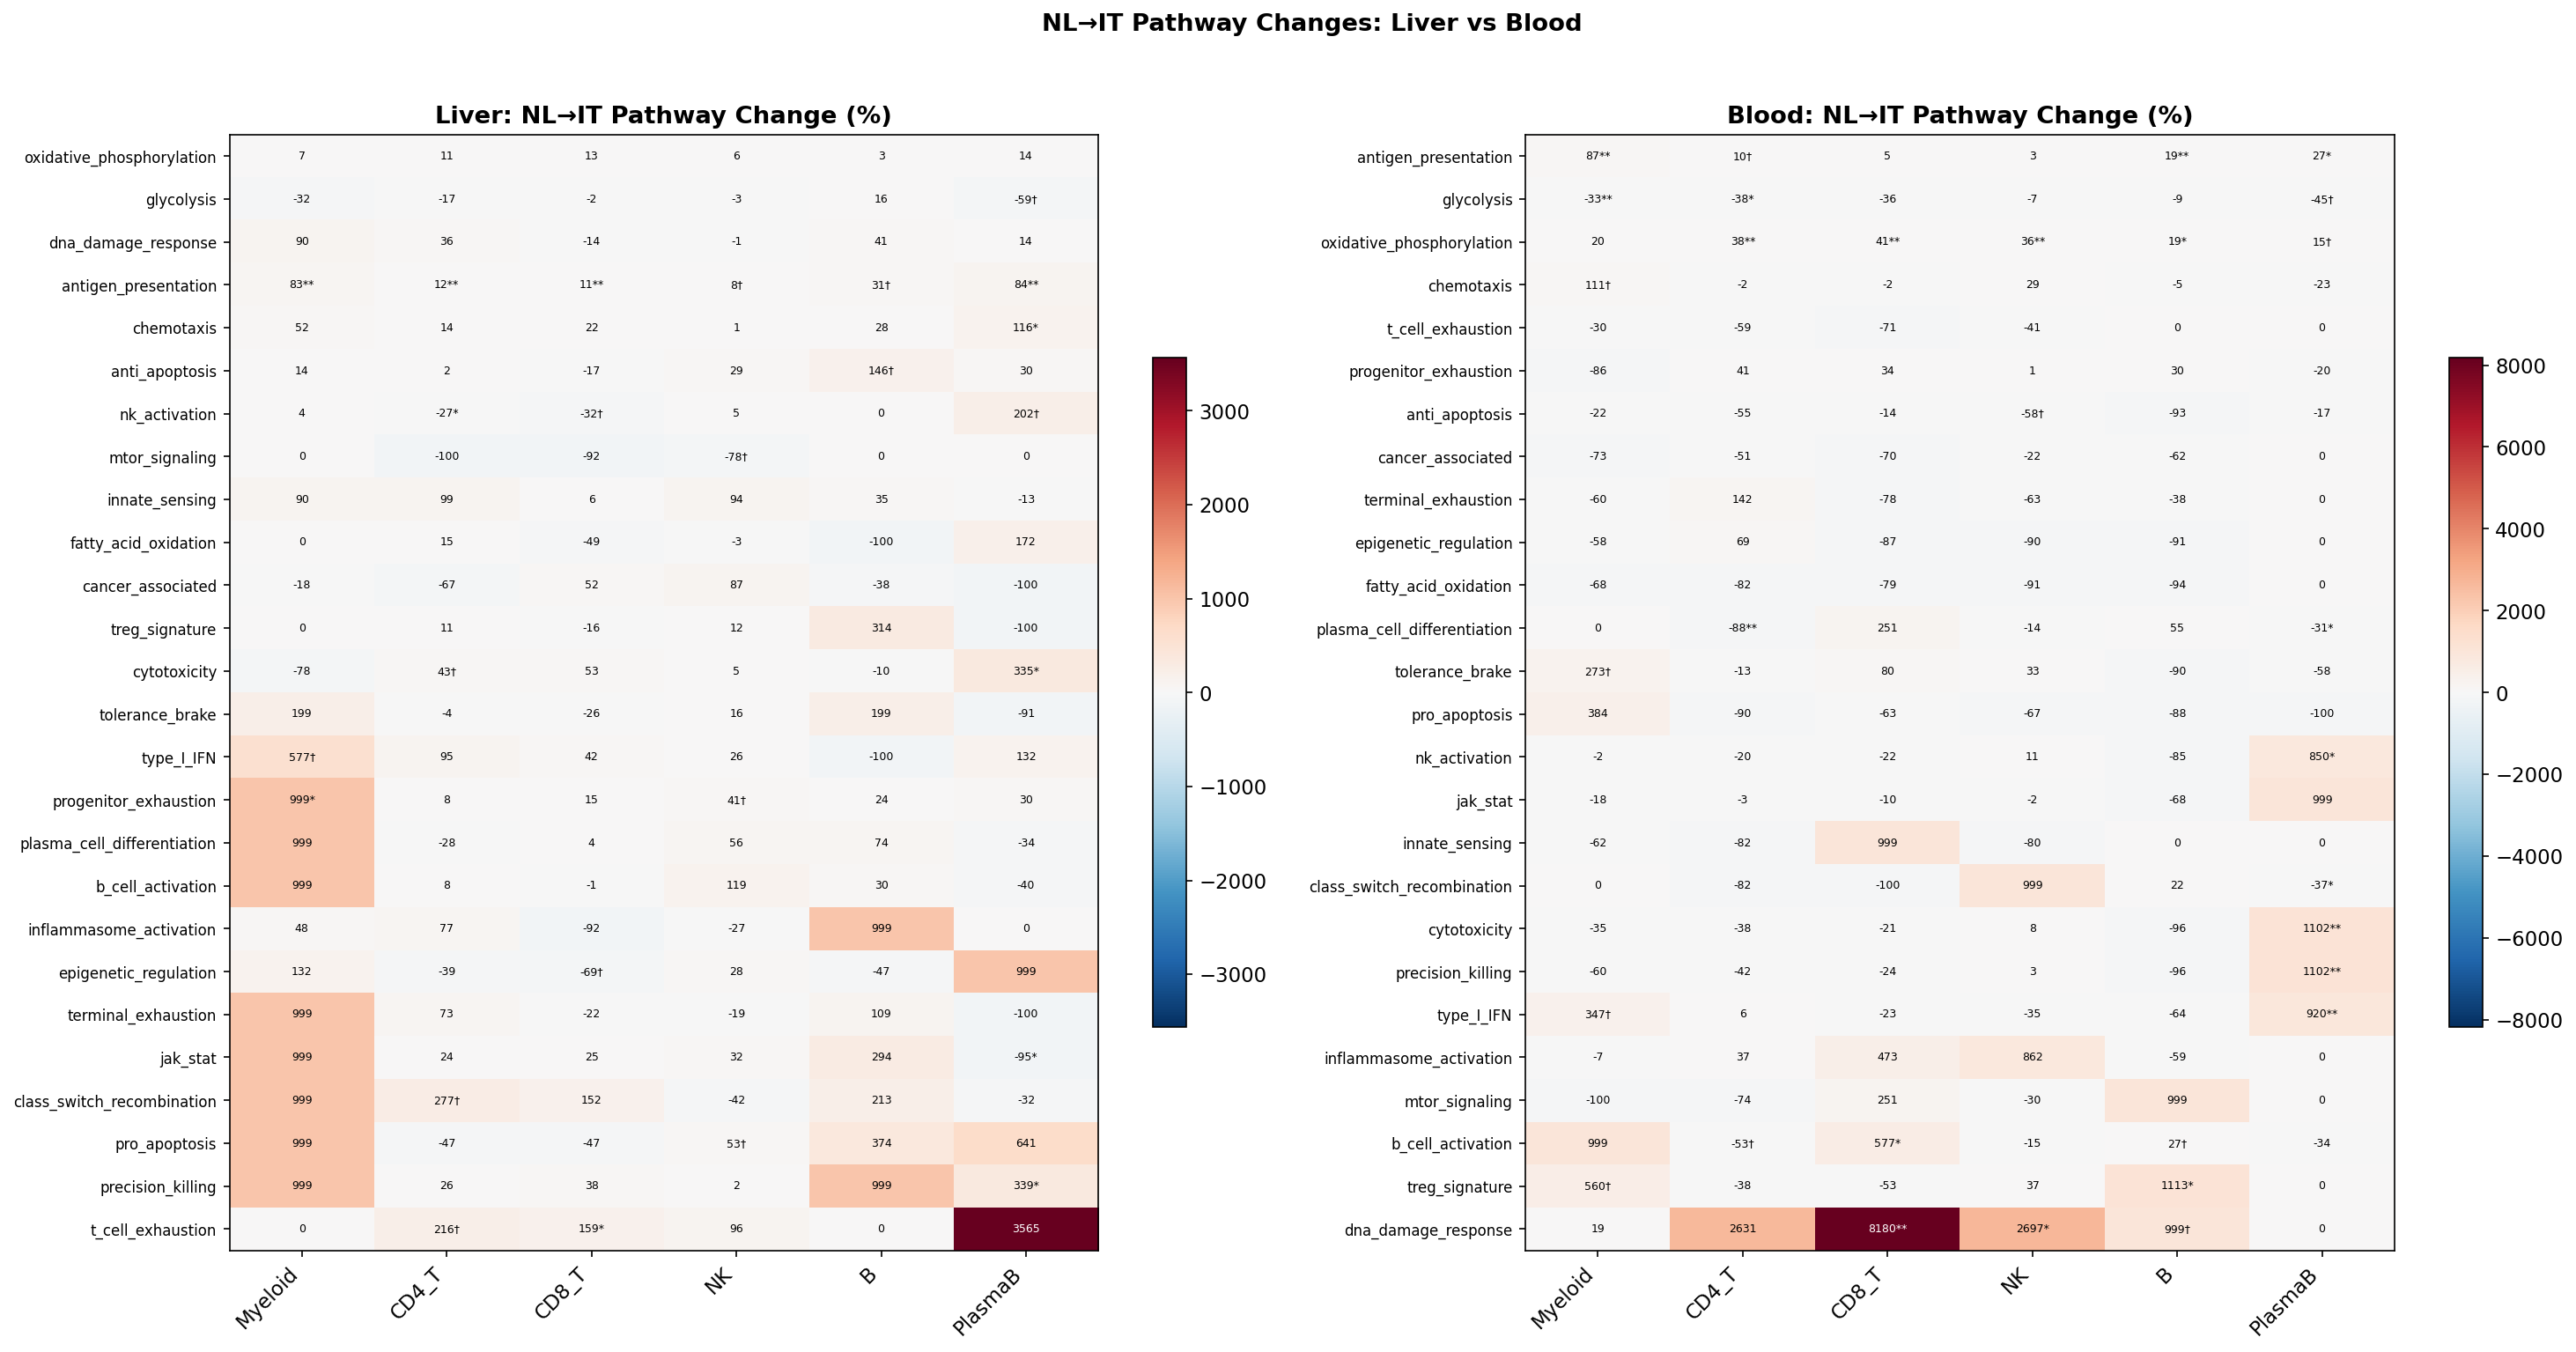

✅ fig_C2_1


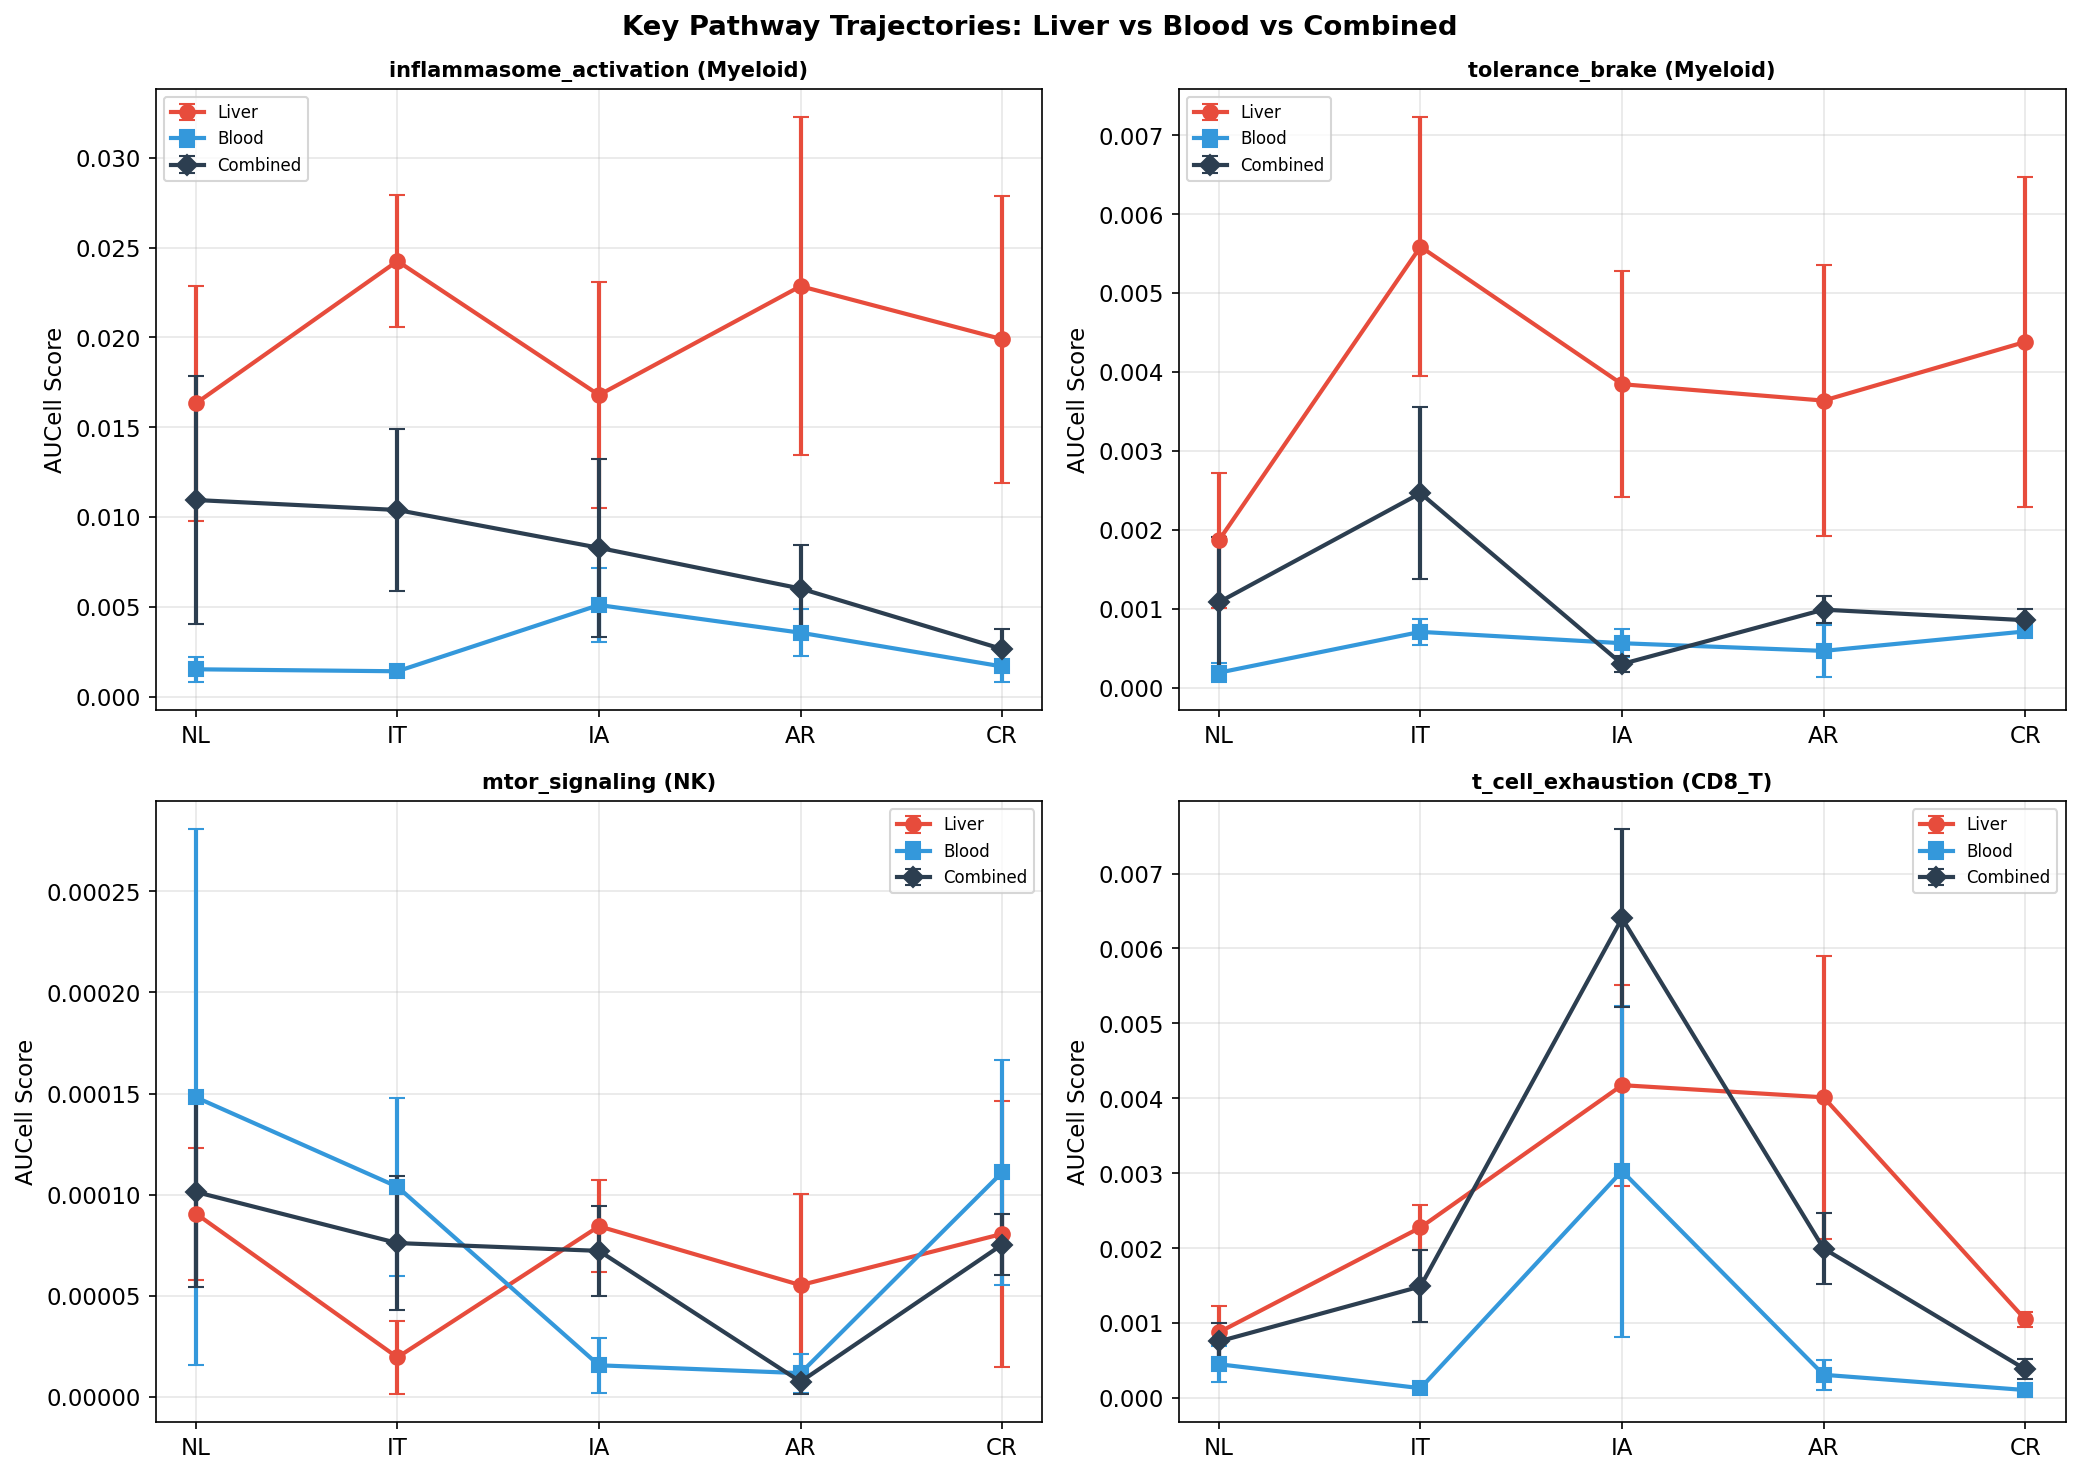

✅ fig_C2_2


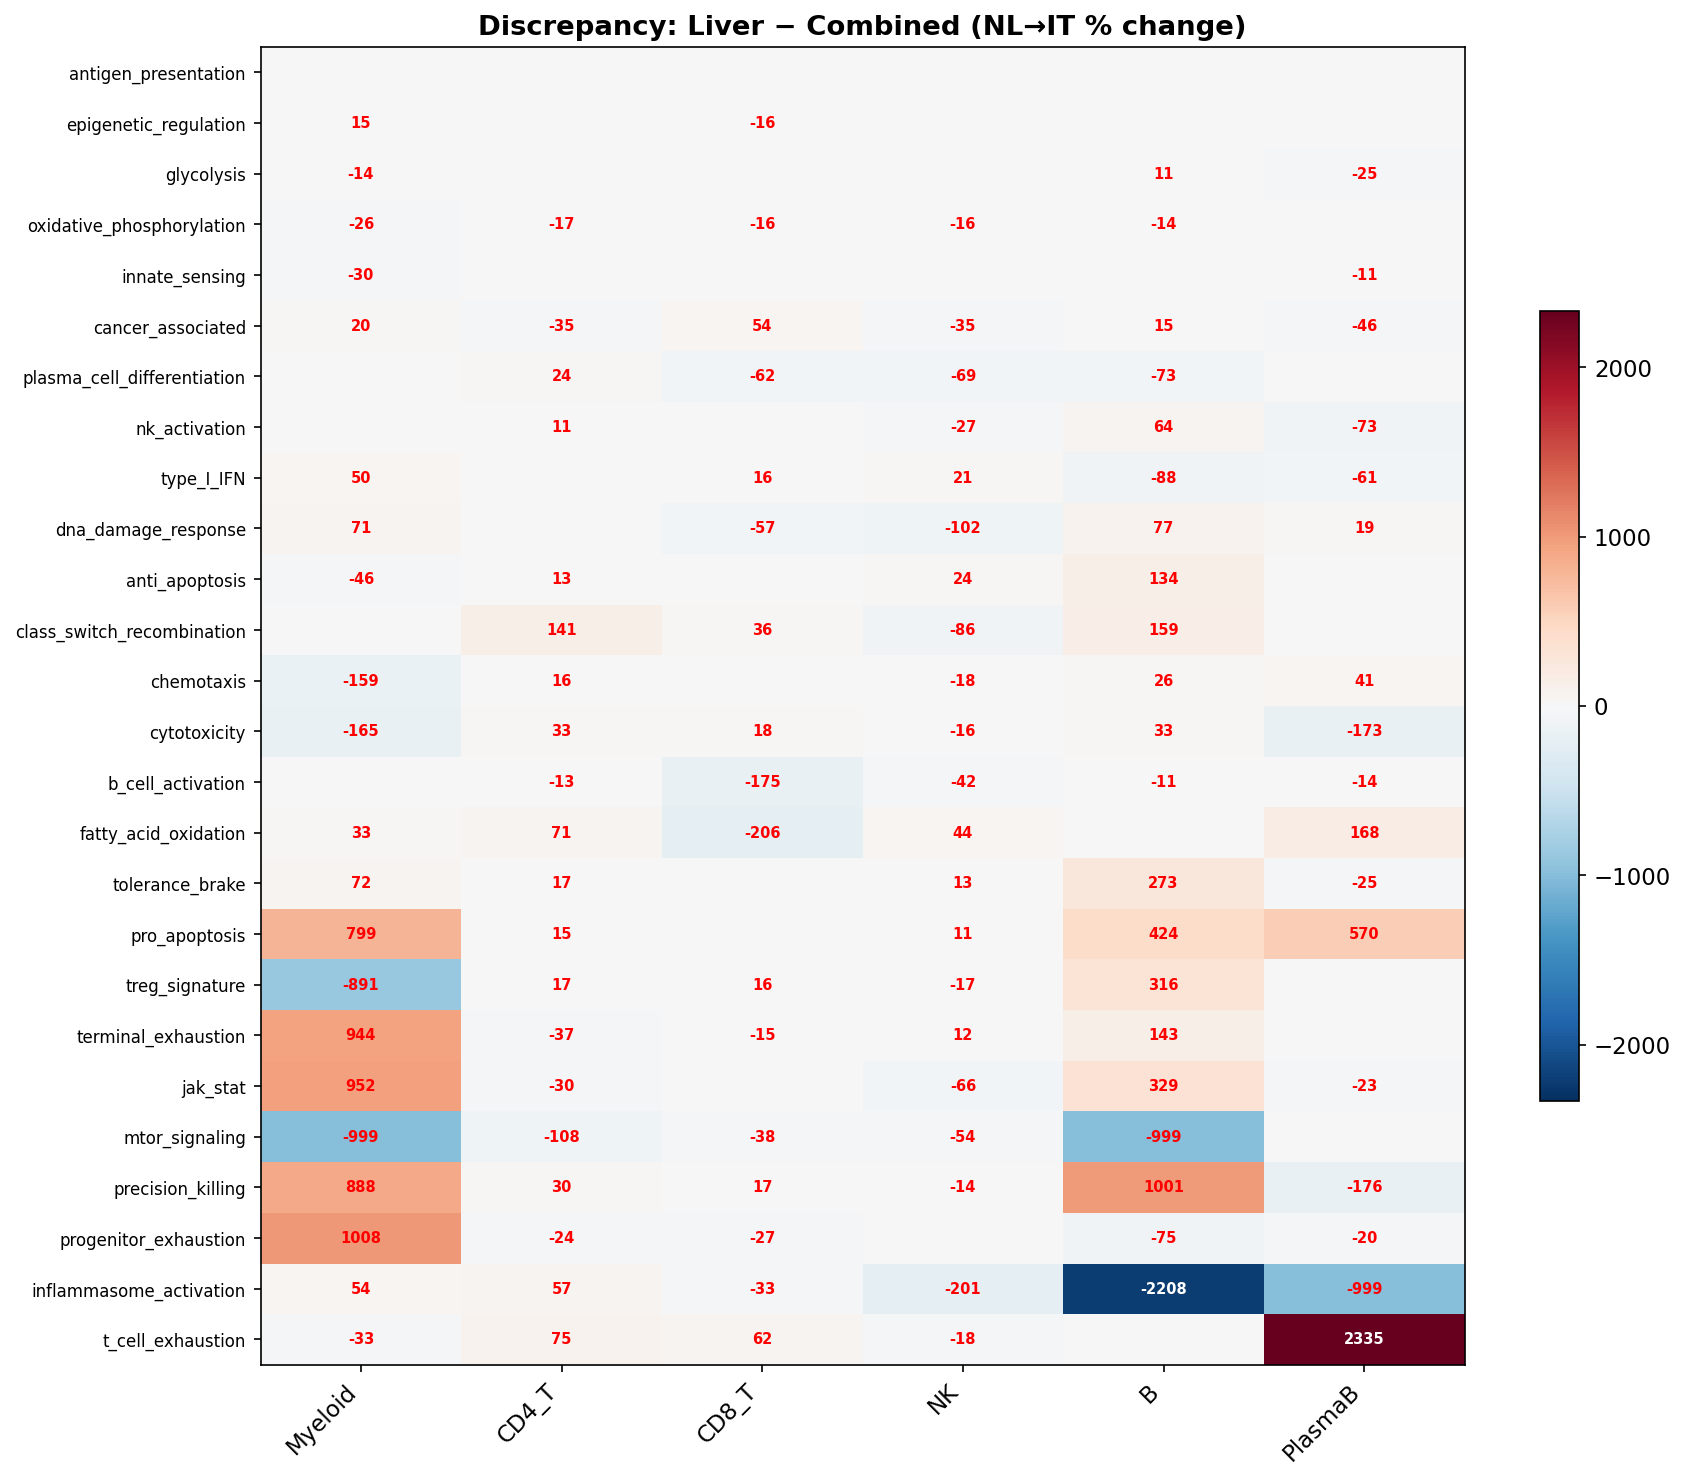

✅ fig_C2_3


In [34]:
# ============================================================
# 8. FIGURES
# ============================================================
print("\n" + "=" * 70)
print("Section 8: FIGURES")
print("=" * 70)

import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.size'] = 11
matplotlib.rcParams['figure.dpi'] = 150

# --- Figure C2-1: NL→IT heatmap ---
fig, axes = plt.subplots(1, 2, figsize=(20, 10))

for i, tissue in enumerate(['Liver', 'Blood']):
    mask = ((df_all_stats['tissue'] == tissue) & (df_all_stats['comparison'] == 'NL→IT'))
    it_df = df_all_stats[mask]

    pivot = it_df.pivot_table(index='pathway', columns='lineage', values='pct_change', aggfunc='first')
    lin_cols = [l for l in lineage_order if l in pivot.columns]
    pivot = pivot.reindex(columns=lin_cols)

    pivot['abs_mean'] = pivot.abs().mean(axis=1)
    pivot = pivot.sort_values('abs_mean', ascending=True).drop('abs_mean', axis=1)

    vmax = max(abs(pivot.values[~np.isnan(pivot.values)].min()),
               abs(pivot.values[~np.isnan(pivot.values)].max()), 50)

    im = axes[i].imshow(pivot.values, cmap='RdBu_r', aspect='auto', vmin=-vmax, vmax=vmax)
    axes[i].set_xticks(range(len(lin_cols)))
    axes[i].set_xticklabels(lin_cols, rotation=45, ha='right')
    axes[i].set_yticks(range(len(pivot)))
    axes[i].set_yticklabels(pivot.index, fontsize=8)
    axes[i].set_title(f'{tissue}: NL→IT Pathway Change (%)', fontweight='bold')

    for y in range(len(pivot)):
        for x in range(len(lin_cols)):
            val = pivot.values[y, x]
            if not np.isnan(val):
                sig_row = it_df[(it_df['pathway'] == pivot.index[y]) & (it_df['lineage'] == lin_cols[x])]
                sig_mark = sig_row['sig'].values[0] if len(sig_row) > 0 and sig_row['sig'].values[0] != 'NS' else ''
                axes[i].text(x, y, f'{val:.0f}{sig_mark}', ha='center', va='center',
                           fontsize=6, color='white' if abs(val) > vmax*0.5 else 'black')

    plt.colorbar(im, ax=axes[i], shrink=0.6)

plt.suptitle('NL→IT Pathway Changes: Liver vs Blood', fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/fig_C2_1_NL_IT_pathway_heatmap_liver_blood.png', dpi=200, bbox_inches='tight')
plt.show()
print("✅ fig_C2_1")

# --- Figure C2-2: Key pathway trajectories ---
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
focus_pathways = [
    ('inflammasome_activation', 'Myeloid'),
    ('tolerance_brake', 'Myeloid'),
    ('mtor_signaling', 'NK'),
    ('t_cell_exhaustion', 'CD8_T')
]

for idx, (pathway, focus_lin) in enumerate(focus_pathways):
    ax = axes[idx // 2][idx % 2]

    if pathway not in pathway_cols:
        ax.set_title(f'{pathway}: NOT SCORED')
        continue

    for tissue, color, marker in [('Liver', '#E74C3C', 'o'), ('Blood', '#3498DB', 's'), ('Combined', '#2C3E50', 'D')]:
        donor_df = donor_results[tissue]
        lin_df = donor_df[donor_df['major_lineage'] == focus_lin]

        means, sems = [], []
        for stage in stage_order:
            vals = lin_df[lin_df['Stage'] == stage][pathway].values
            if len(vals) > 0:
                means.append(vals.mean())
                sems.append(vals.std() / np.sqrt(len(vals)) if len(vals) > 1 else 0)
            else:
                means.append(np.nan)
                sems.append(0)

        ax.errorbar(range(len(stage_order)), means, yerr=sems,
                    marker=marker, color=color, linewidth=2, markersize=7,
                    capsize=4, label=tissue)

    ax.set_xticks(range(len(stage_order)))
    ax.set_xticklabels(stage_order)
    ax.set_title(f'{pathway} ({focus_lin})', fontweight='bold', fontsize=10)
    ax.set_ylabel('AUCell Score')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.suptitle('Key Pathway Trajectories: Liver vs Blood vs Combined', fontweight='bold')
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/fig_C2_2_key_pathway_trajectories.png', dpi=200, bbox_inches='tight')
plt.show()
print("✅ fig_C2_2")

# --- Figure C2-3: Discrepancy ---
fig, ax = plt.subplots(figsize=(12, 10))
disc_data = []
for pathway in pathway_cols:
    row = {'pathway': pathway}
    for lineage in lineage_order:
        l_mask = ((df_all_stats['tissue'] == 'Liver') & (df_all_stats['comparison'] == 'NL→IT') &
                  (df_all_stats['pathway'] == pathway) & (df_all_stats['lineage'] == lineage))
        c_mask = ((df_all_stats['tissue'] == 'Combined') & (df_all_stats['comparison'] == 'NL→IT') &
                  (df_all_stats['pathway'] == pathway) & (df_all_stats['lineage'] == lineage))
        l_row = df_all_stats[l_mask]
        c_row = df_all_stats[c_mask]
        if len(l_row) > 0 and len(c_row) > 0:
            row[lineage] = l_row['pct_change'].values[0] - c_row['pct_change'].values[0]
        else:
            row[lineage] = 0
    disc_data.append(row)

disc_df = pd.DataFrame(disc_data).set_index('pathway')
disc_df = disc_df[[l for l in lineage_order if l in disc_df.columns]]
disc_df['abs_max'] = disc_df.abs().max(axis=1)
disc_df = disc_df.sort_values('abs_max', ascending=True).drop('abs_max', axis=1)

vmax_d = max(abs(disc_df.values.min()), abs(disc_df.values.max()), 20)
im = ax.imshow(disc_df.values, cmap='RdBu_r', aspect='auto', vmin=-vmax_d, vmax=vmax_d)
ax.set_xticks(range(len(disc_df.columns)))
ax.set_xticklabels(disc_df.columns, rotation=45, ha='right')
ax.set_yticks(range(len(disc_df)))
ax.set_yticklabels(disc_df.index, fontsize=8)
ax.set_title('Discrepancy: Liver − Combined (NL→IT % change)', fontweight='bold')
plt.colorbar(im, ax=ax, shrink=0.6)

for y in range(len(disc_df)):
    for x in range(len(disc_df.columns)):
        val = disc_df.values[y, x]
        if abs(val) > 10:
            ax.text(x, y, f'{val:.0f}', ha='center', va='center', fontsize=7,
                   color='white' if abs(val) > vmax_d*0.5 else 'red', fontweight='bold')

plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/fig_C2_3_discrepancy_liver_vs_combined.png', dpi=200, bbox_inches='tight')
plt.show()
print("✅ fig_C2_3")

In [35]:
# ============================================================
# 9. SUMMARY
# ============================================================
print("\n" + "=" * 70)
print("v18-C2 COMPLETE SUMMARY")
print("=" * 70)

sig_liver = len(df_all_stats[(df_all_stats['tissue'] == 'Liver') & (df_all_stats['p_value'] < 0.05)])
sig_blood = len(df_all_stats[(df_all_stats['tissue'] == 'Blood') & (df_all_stats['p_value'] < 0.05)])
sig_combined = len(df_all_stats[(df_all_stats['tissue'] == 'Combined') & (df_all_stats['p_value'] < 0.05)])

summary = f"""
v18-C2: AUCell PATHWAY SCORING (Tissue-Separated, GPU-accelerated)
{'='*60}
Method: AUCell v3 (GPU, zero-aware ranking)
Gene sets: {len(pathway_cols)} scored
Cells: Liver={aucell_results['Liver'].shape[0]:,}, Blood={aucell_results['Blood'].shape[0]:,}

SIGNIFICANT FINDINGS (p<0.05):
  Liver: {sig_liver}
  Blood: {sig_blood}
  Combined: {sig_combined}

FILES: {SAVE_DIR}
STATUS: ✅ C2 COMPLETE — Ready for C3
"""
print(summary)

with open(f'{SAVE_DIR}/C2_summary.txt', 'w') as f:
    f.write(summary)

print("=" * 70)
print("v18-C2 COMPLETE")
print("=" * 70)


v18-C2 COMPLETE SUMMARY

v18-C2: AUCell PATHWAY SCORING (Tissue-Separated, GPU-accelerated)
Method: AUCell v3 (GPU, zero-aware ranking)
Gene sets: 26 scored
Cells: Liver=106,592, Blood=136,408

SIGNIFICANT FINDINGS (p<0.05):
  Liver: 63
  Blood: 76
  Combined: 95

FILES: /content/drive/MyDrive/ITLAS/results/version18-analysis/C2_pathway/
STATUS: ✅ C2 COMPLETE — Ready for C3

v18-C2 COMPLETE


In [36]:
import os
f = '/content/drive/MyDrive/ITLAS/results/version18-analysis/C2_pathway/fig_C2_2_key_pathway_trajectories.png'
if os.path.exists(f):
    os.remove(f)
    print("✅ 삭제완료: fig_C2_2_key_pathway_trajectories.png")

✅ 삭제완료: fig_C2_2_key_pathway_trajectories.png
